## Load the main tracking CSV

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tifffile

output_folder = r"C:\Users\virsi\Documents\Ana Franz\_Github_test\microns"

# Load outputs from the new pipeline
tracking_df   = pd.read_csv(f"{output_folder}/tracking.csv")
lifespans_df  = pd.read_csv(f"{output_folder}/lifespans.csv")
boundaries_df = pd.read_csv(f"{output_folder}/boundaries.csv")
trajectories_df = pd.read_csv(f"{output_folder}/trajectories.csv")
tracked_stack = tifffile.imread(f"{output_folder}/tracked_stack.tif")

print(f"Tracking records: {len(tracking_df)}")
print(f"Lifespans: {len(lifespans_df)}")
print(f"Boundaries: {len(boundaries_df)}")
print(f"Trajectories: {len(trajectories_df)}")
print(f"Tracked stack shape: {tracked_stack.shape}")

Tracking records: 1895
Lifespans: 31
Boundaries: 1013846
Trajectories: 25
Tracked stack shape: (121, 1024, 1024)


## Per cell summary and global stats

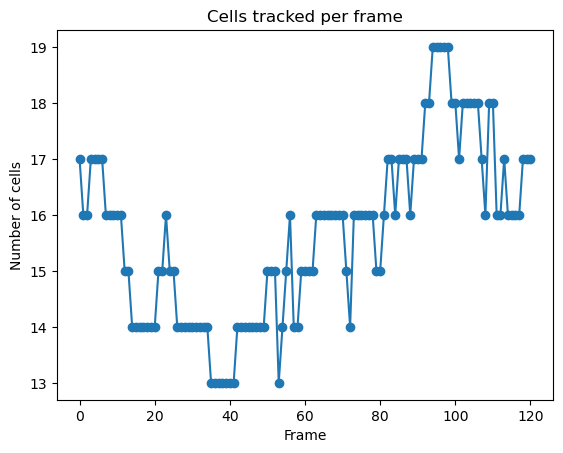

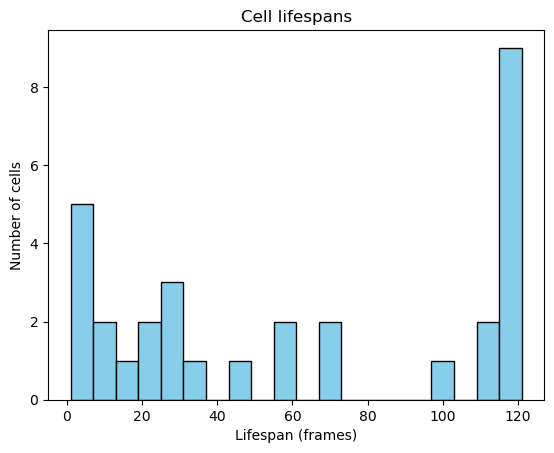

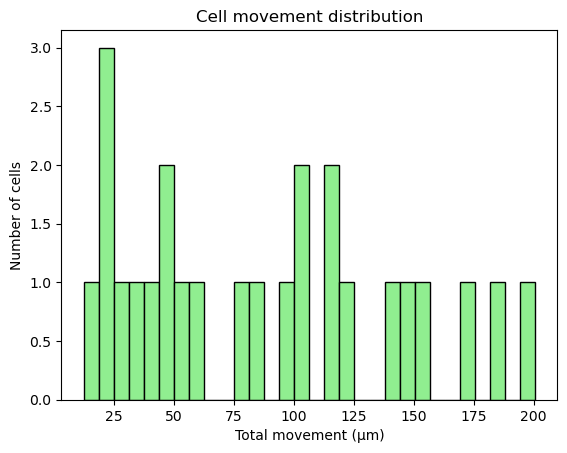

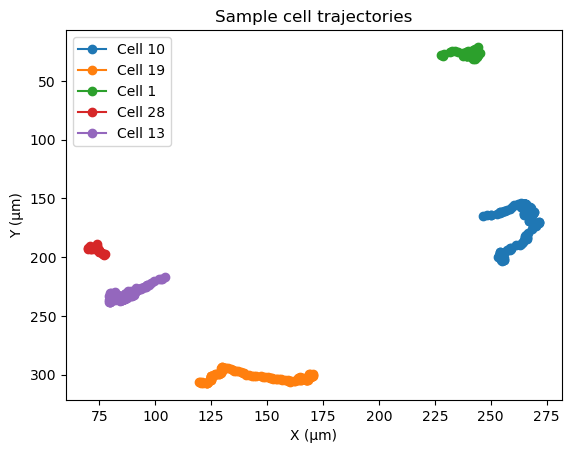

In [2]:


# Cells per frame
cells_per_frame = tracking_df.groupby('timepoint')['global_id'].nunique()
fig = cells_per_frame.plot(marker='o', title='Cells tracked per frame')
plt.xlabel("Frame")
plt.ylabel("Number of cells")
plt.savefig("cells_per_frame.png")
plt.show()

# Cell lifespans
lifespans = tracking_df.groupby('global_id')['timepoint'].agg(['min','max'])
lifespans['lifespan'] = lifespans['max'] - lifespans['min'] + 1
plt.figure()
plt.hist(lifespans['lifespan'], bins=20, color='skyblue', edgecolor='k')
plt.xlabel("Lifespan (frames)")
plt.ylabel("Number of cells")
plt.title("Cell lifespans")
plt.savefig("cell_lifespans.png")
plt.show()

# Movement distances
plt.figure()
plt.hist(trajectories_df['total_distance_um'], bins=30, color='lightgreen', edgecolor='k')
plt.xlabel("Total movement (µm)")
plt.ylabel("Number of cells")
plt.title("Cell movement distribution")
plt.savefig("movement_distances.png")
plt.show()

# Sample trajectories
plt.figure()
sample_cells = trajectories_df['cell_id'].sample(min(5, len(trajectories_df)), random_state=42)
for cid in sample_cells:
    cell_data = tracking_df[tracking_df['global_id']==cid].sort_values('timepoint')
    plt.plot(cell_data['centroid_x_um'], cell_data['centroid_y_um'], marker='o', label=f'Cell {cid}')
plt.xlabel("X (µm)")
plt.ylabel("Y (µm)")
plt.title("Sample cell trajectories")
plt.gca().invert_yaxis()
plt.legend()
plt.savefig("sample_trajectories.png")
plt.show()

## Validation and consistency

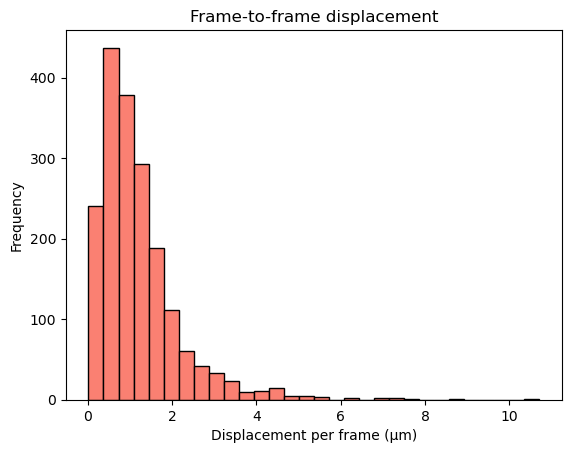

Mean displacement: 1.20 µm
Max displacement: 10.71 µm


In [3]:
# Frame-to-frame displacement
displacements = []

for cid, df in tracking_df.groupby('global_id'):
    df = df.sort_values('timepoint')
    coords = df[['centroid_x_um', 'centroid_y_um']].values

    if len(coords) > 1:
        d = np.sqrt(np.sum(np.diff(coords, axis=0)**2, axis=1))
        displacements.extend(d)

plt.figure()
plt.hist(displacements, bins=30, color='salmon', edgecolor='k')
plt.xlabel("Displacement per frame (µm)")
plt.ylabel("Frequency")
plt.title("Frame-to-frame displacement")
plt.savefig("frame_displacement.png")
plt.show()

print(f"Mean displacement: {np.mean(displacements):.2f} µm")
print(f"Max displacement: {np.max(displacements):.2f} µm")

In [4]:
suspicious = []

threshold = 0.8 * 15  # µm (adapt if needed)

for cid, df in tracking_df.groupby('global_id'):
    df = df.sort_values('timepoint')
    coords = df[['centroid_x_um', 'centroid_y_um']].values

    if len(coords) > 1:
        d = np.sqrt(np.sum(np.diff(coords, axis=0)**2, axis=1))
        if np.any(d > threshold):
            suspicious.append(cid)

print(f"Suspicious cells: {len(suspicious)}")

Suspicious cells: 0
